In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Emoji dataset
emojis = {
    "❤️": ["I love this", "You  amazing", "Feeling blessed", "Much love", "Warm hugs"],
    "😀": ["Feeling happy", "Best day ever", "So excited!", "Big smile", "Great mood"],
    "😢": ["Feeling low", "So sad", "Broken heart", "Crying now", "Tears in my eyes"],
    "😡": ["I hate this", "Very angry", "Totally mad", "Boiling with rage", "I’m upset!"],
    "😂": ["So funny!", "Can’t stop laughing", "LMAO", "ROFL", "That cracked me up!"],
    "😴": ["Need sleep", "Yawning", "Sleepy now", "Very tired", "Going to bed"],
    "😲": ["No way!", "That's shocking!", "I can't believe this!", "Unreal!", "What just happened?!"],
    "🎉": ["Congratulations!", "Let’s party", "We did it!", "Big celebration", "Cheers!"]
}
# Generate dataset
texts, labels = [], []
for emoji, samples in emojis.items():
    emoji_count = random.randint(10, 200)
    for _ in range(emoji_count):
        texts.append(random.choice(samples))
        labels.append(emoji)

df = pd.DataFrame({"text": texts, "emoji": labels})

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


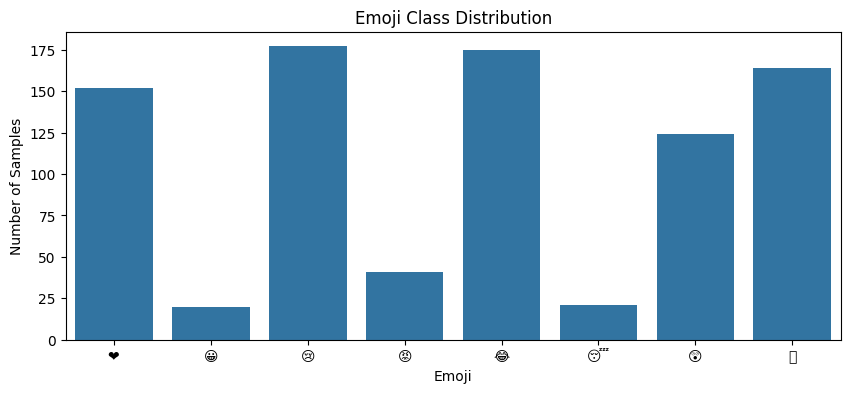

Class distribution:
emoji
😢     177
😂     175
🎉     164
❤️    152
😲     124
😡      41
😴      21
😀      20
Name: count, dtype: int64


In [2]:
plt.figure(figsize=(10, 4))
sns.countplot(x="emoji", data=df)
plt.title("Emoji Class Distribution")
plt.xlabel("Emoji")
plt.ylabel("Number of Samples")
plt.show()
# Show class counts
print("Class distribution:")
print(df["emoji"].value_counts())


In [3]:
X_train, X_test, y_train, y_test = train_test_split(df["text"], df["emoji"], test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")


Training samples: 699
Test samples: 175


In [4]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

train_acc = pipeline.score(X_train, y_train)
test_acc = pipeline.score(X_test, y_test)

print(f"✅ Train Accuracy: {train_acc:.2f}")
print(f"✅ Test Accuracy: {test_acc:.2f}")


✅ Train Accuracy: 1.00
✅ Test Accuracy: 0.98


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


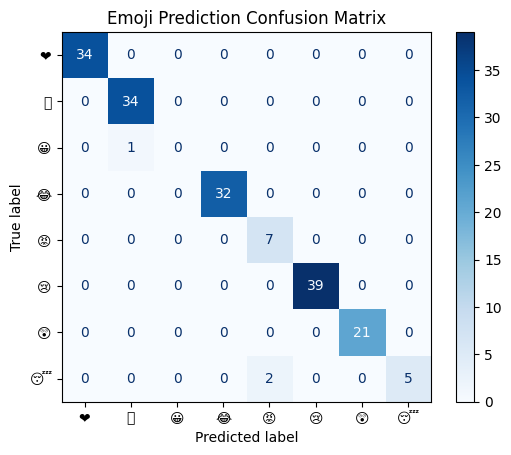

In [5]:
y_pred = pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=pipeline.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Emoji Prediction Confusion Matrix")
plt.show()


In [6]:
def predict_emoji(text):
    prediction = pipeline.predict([text])[0]
    print(f"📝 Input: '{text}' ➡️ Predicted Emoji: {prediction}")

# Students can test
predict_emoji("I'm so sleepy")
predict_emoji("That was hilarious")
predict_emoji("I’m furious!")
predict_emoji("We won the trophy!")
predict_emoji("Such a sweet gesture")


📝 Input: 'I'm so sleepy' ➡️ Predicted Emoji: 😂
📝 Input: 'That was hilarious' ➡️ Predicted Emoji: 😲
📝 Input: 'I’m furious!' ➡️ Predicted Emoji: 🎉
📝 Input: 'We won the trophy!' ➡️ Predicted Emoji: 🎉
📝 Input: 'Such a sweet gesture' ➡️ Predicted Emoji: 🎉


In [7]:
while True:
    user_input = input("Type a sentence to predict emoji (or 'exit'): ")
    if user_input.lower() == 'exit':
        break
    predict_emoji(user_input)


Type a sentence to predict emoji (or 'exit'): i am happy
📝 Input: 'i am happy' ➡️ Predicted Emoji: 😀
Type a sentence to predict emoji (or 'exit'): i am angry
📝 Input: 'i am angry' ➡️ Predicted Emoji: 😡
Type a sentence to predict emoji (or 'exit'): funny
📝 Input: 'funny' ➡️ Predicted Emoji: 😂
Type a sentence to predict emoji (or 'exit'): cry
📝 Input: 'cry' ➡️ Predicted Emoji: 🎉
Type a sentence to predict emoji (or 'exit'): exit
